In [1]:
!pip install pydicom==2.4.4

In [2]:
!pip install -q kaggle

from google.colab import files
files.upload()  # selecione o kaggle.json que você baixou

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"felipezeiser","key":"9891f2ad99510bd72e353a73e923c23a"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
DEST="/content/drive/MyDrive/dados_rsna"
!mkdir -p "$DEST"


In [6]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p "$DEST"


rsna-pneumonia-detection-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
!unzip -q  "$DEST/rsna-pneumonia-detection-challenge.zip" -d "$DEST"

replace /content/drive/MyDrive/dados_rsna/GCP Credits Request Link - RSNA.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/dados_rsna/stage_2_detailed_class_info.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/dados_rsna/stage_2_sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/dados_rsna/stage_2_test_images/0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/drive/MyDrive/dados_rsna/stage_2_test_images/0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [8]:
!ls /content/drive/MyDrive/dados_rsna/

'GCP Credits Request Link - RSNA.txt'	  stage_2_test_images
 rsna-pneumonia-detection-challenge.zip   stage_2_train_images
 stage_2_detailed_class_info.csv	  stage_2_train_labels.csv
 stage_2_sample_submission.csv


In [9]:
import pandas as pd, os
DEST = "/content/drive/MyDrive/dados_rsna"
labels = pd.read_csv(os.path.join(DEST, "stage_2_train_labels.csv"))
labels.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [10]:
!ls /content/drive/MyDrive/dados_rsna/stage_2_test_images

0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm
0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm
000686d7-f4fc-448d-97a0-44fa9c5d3aa6.dcm
000e3a7d-c0ca-4349-bb26-5af2d8993c3d.dcm
00100a24-854d-423d-a092-edcf6179e061.dcm
0015597f-2d69-4bc7-b642-5b5e01534676.dcm
001b0c51-c7b3-45c1-9c17-fa7594cab96e.dcm
0022bb50-bf6c-4185-843e-403a9cc1ea80.dcm
00271e8e-aea8-4f0a-8a34-3025831f1079.dcm
0028450f-5b8e-4695-9416-8340b6f686b0.dcm
002bcde0-d8da-4931-ab04-5d724e30261b.dcm
002fcb77-ef76-4626-ab34-5070f15c20db.dcm
003206b4-bd4a-4684-8d49-76f4cb713a30.dcm
00330f7f-d114-4eb2-9c6e-558eeb3084a1.dcm
00342ae8-ff81-4229-adf6-6a2ab711707b.dcm
003d17f0-bd8a-485c-bc8b-daec33f53efa.dcm
003dba79-1b1d-4713-add8-d72c54074f8a.dcm
003ec9e3-512e-4f6e-923d-daa9f9f3db9a.dcm
003fbda2-ba55-4714-a03a-83f15bec19e4.dcm
0041fc67-793c-4129-a952-ea3fb821b445.dcm
00475531-1036-4ab4-8c12-1eac7e9ddfd1.dcm
0048e89e-f88a-41a1-b79f-ab4e7135627e.dcm
004b28ac-d188-427b-8a21-10501125f596.dcm
004f0a0f-fb54-4068-8b67-d3eef6724f44.dcm
004f720d-482c-49

In [13]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt

patientId = labels['patientId'][0]
dcm_file = f'{DEST}/stage_2_train_images/{patientId}.dcm'
dcm_data = pydicom.read_file(dcm_file)

print(dcm_data)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 202
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0002, 0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002, 0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002, 0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008, 0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0008, 0020) Study Date                          DA: '19010101'
(0008, 0030) Study Time      

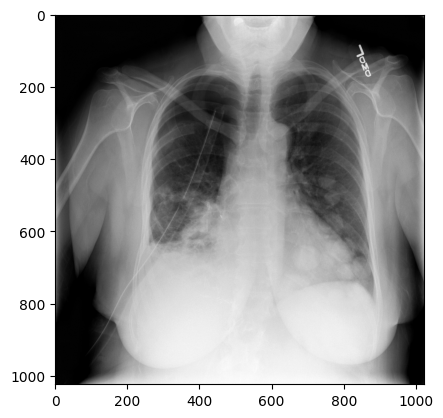

In [14]:
im = dcm_data.pixel_array

plt.imshow(im, cmap='gray')
plt.show()